In [1]:
# ================================
# 1. CARGA DE DATOS
# ================================
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import chi2_contingency, kruskal
warnings.filterwarnings('ignore')

ruta_db = "../database/proyecto_analitica.db"
conn = sqlite3.connect(ruta_db)
df = pd.read_sql_query("SELECT * FROM muestra", conn)
conn.close()
print("Dimensiones originales:", df.shape)

Dimensiones originales: (5882680, 10)


In [ ]:
# 2. FEATURE ENGINEERING BÁSICO (Clasificación original en 4 niveles)
df['num_movimientos'] = df['Moves'].str.split().str.len()
df['num_temas'] = df['Themes'].str.split().str.len()

# Asegurar Rating como entero (el ELO)
df['Rating'] = df['Rating'].astype(int)

# Bins y Labels s
bins = [float('-inf'), 1200, 1800, 2400, float('inf')]
labels = ['Principiante', 'Intermedio', 'Avanzado', 'Maestro']

# Crear la variable objetivo categórica
df['nivel_dificultad'] = pd.cut(df['Rating'], bins=bins, labels=labels, right=False)

# Ver la nueva distribución de las clases
conteo = df['nivel_dificultad'].value_counts().reindex(labels)
print("--- Distribución de clases ---")
print(conteo)
print(f"\n--- Porcentaje por clase ---")
print((conteo / len(df) * 100).round(2).astype(str) + '%')

--- Distribución de clases ---
nivel_dificultad
Principiante    2127056
Intermedio      2060929
Avanzado        1356106
Maestro          338589
Name: count, dtype: int64

--- Porcentaje por clase ---
nivel_dificultad
Principiante    36.16%
Intermedio      35.03%
Avanzado        23.05%
Maestro          5.76%
Name: count, dtype: str


In [12]:
# ================================
# 3. TIPOS DE VARIABLES
# ================================
# Columnas útiles para análisis
num_cols = ['Rating', 'RatingDeviation', 'Popularity', 'NbPlays', 
            'num_movimientos', 'num_temas']
cat_cols = ['nivel_dificultad', 'Themes']  # Themes es texto multilabel
# Identificadores no útiles para EDA: PuzzleId, FEN, Moves, GameUrl, OpeningTags

print("Variables numéricas:", num_cols)
print("Variable categórica objetivo:", 'nivel_dificultad')

Variables numéricas: ['Rating', 'RatingDeviation', 'Popularity', 'NbPlays', 'num_movimientos', 'num_temas']
Variable categórica objetivo: nivel_dificultad


In [13]:
# ================================
# 4. ANÁLISIS DESCRIPTIVO
# ================================
desc_num = df[num_cols].describe().T
desc_num['mediana'] = df[num_cols].median()
print("Estadísticas numéricas:")
display(desc_num[['mean', 'mediana', 'std', 'min', 'max']].round(2))


Estadísticas numéricas:


,mean,mediana,std,min,max
Rating,1477.07,1424.0,547.19,399.0,3329.0
RatingDeviation,86.95,79.0,25.58,45.0,500.0
Popularity,86.13,90.0,14.10,-83.0,100.0
NbPlays,1679.84,365.0,4544.50,0.0,312634.0
num_movimientos,4.64,4.0,1.85,2.0,34.0
num_temas,4.54,4.0,1.12,1.0,13.0


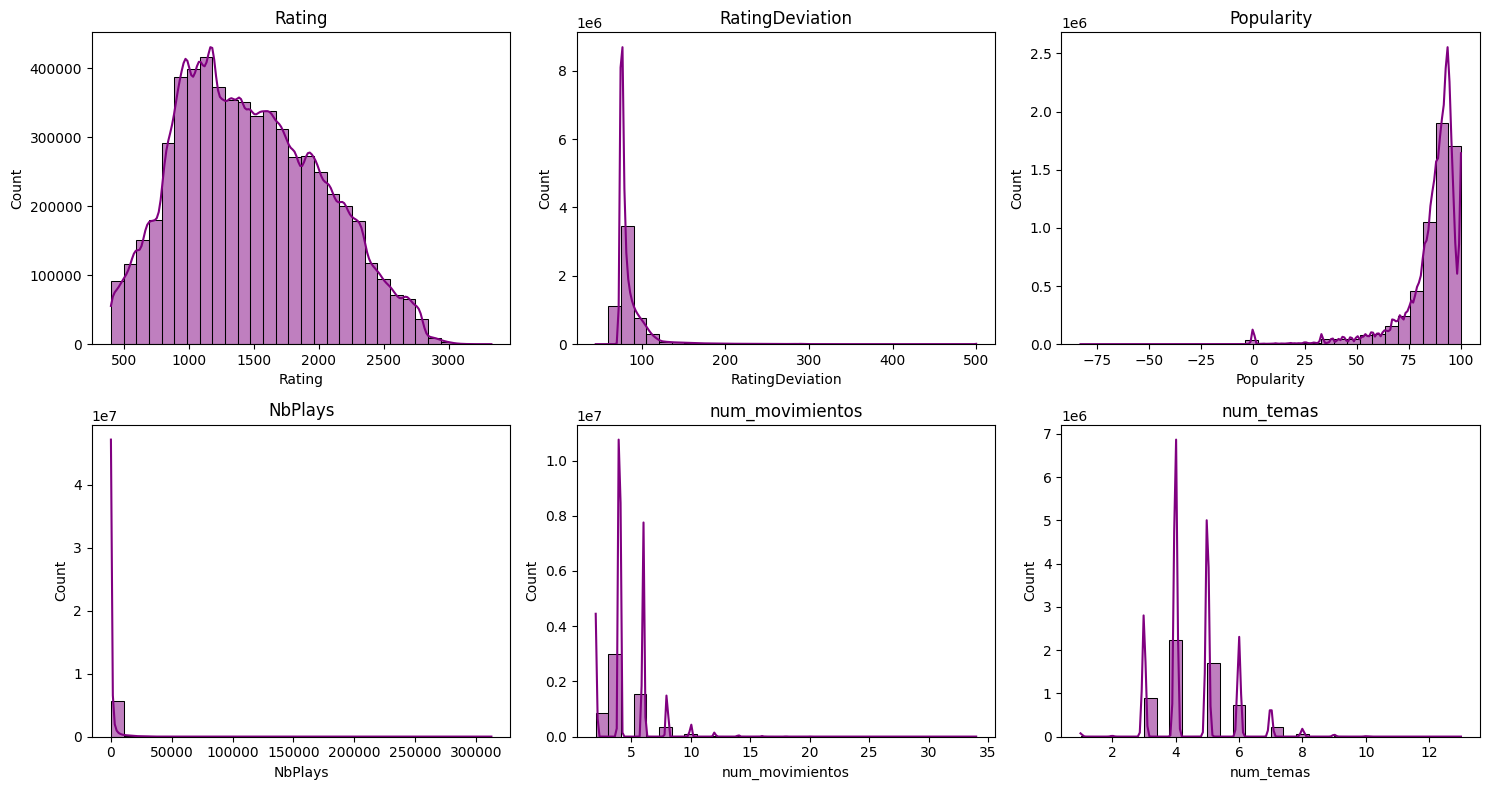

In [14]:
# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='purple')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [15]:
# ================================
# 5. VALORES ATÍPICOS
# ================================
print("\n🔍 Outliers por variable:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


🔍 Outliers por variable:
Rating: 83 (0.00%)
RatingDeviation: 455762 (7.75%)
Popularity: 414255 (7.04%)
NbPlays: 731758 (12.44%)
num_movimientos: 140514 (2.39%)
num_temas: 330509 (5.62%)


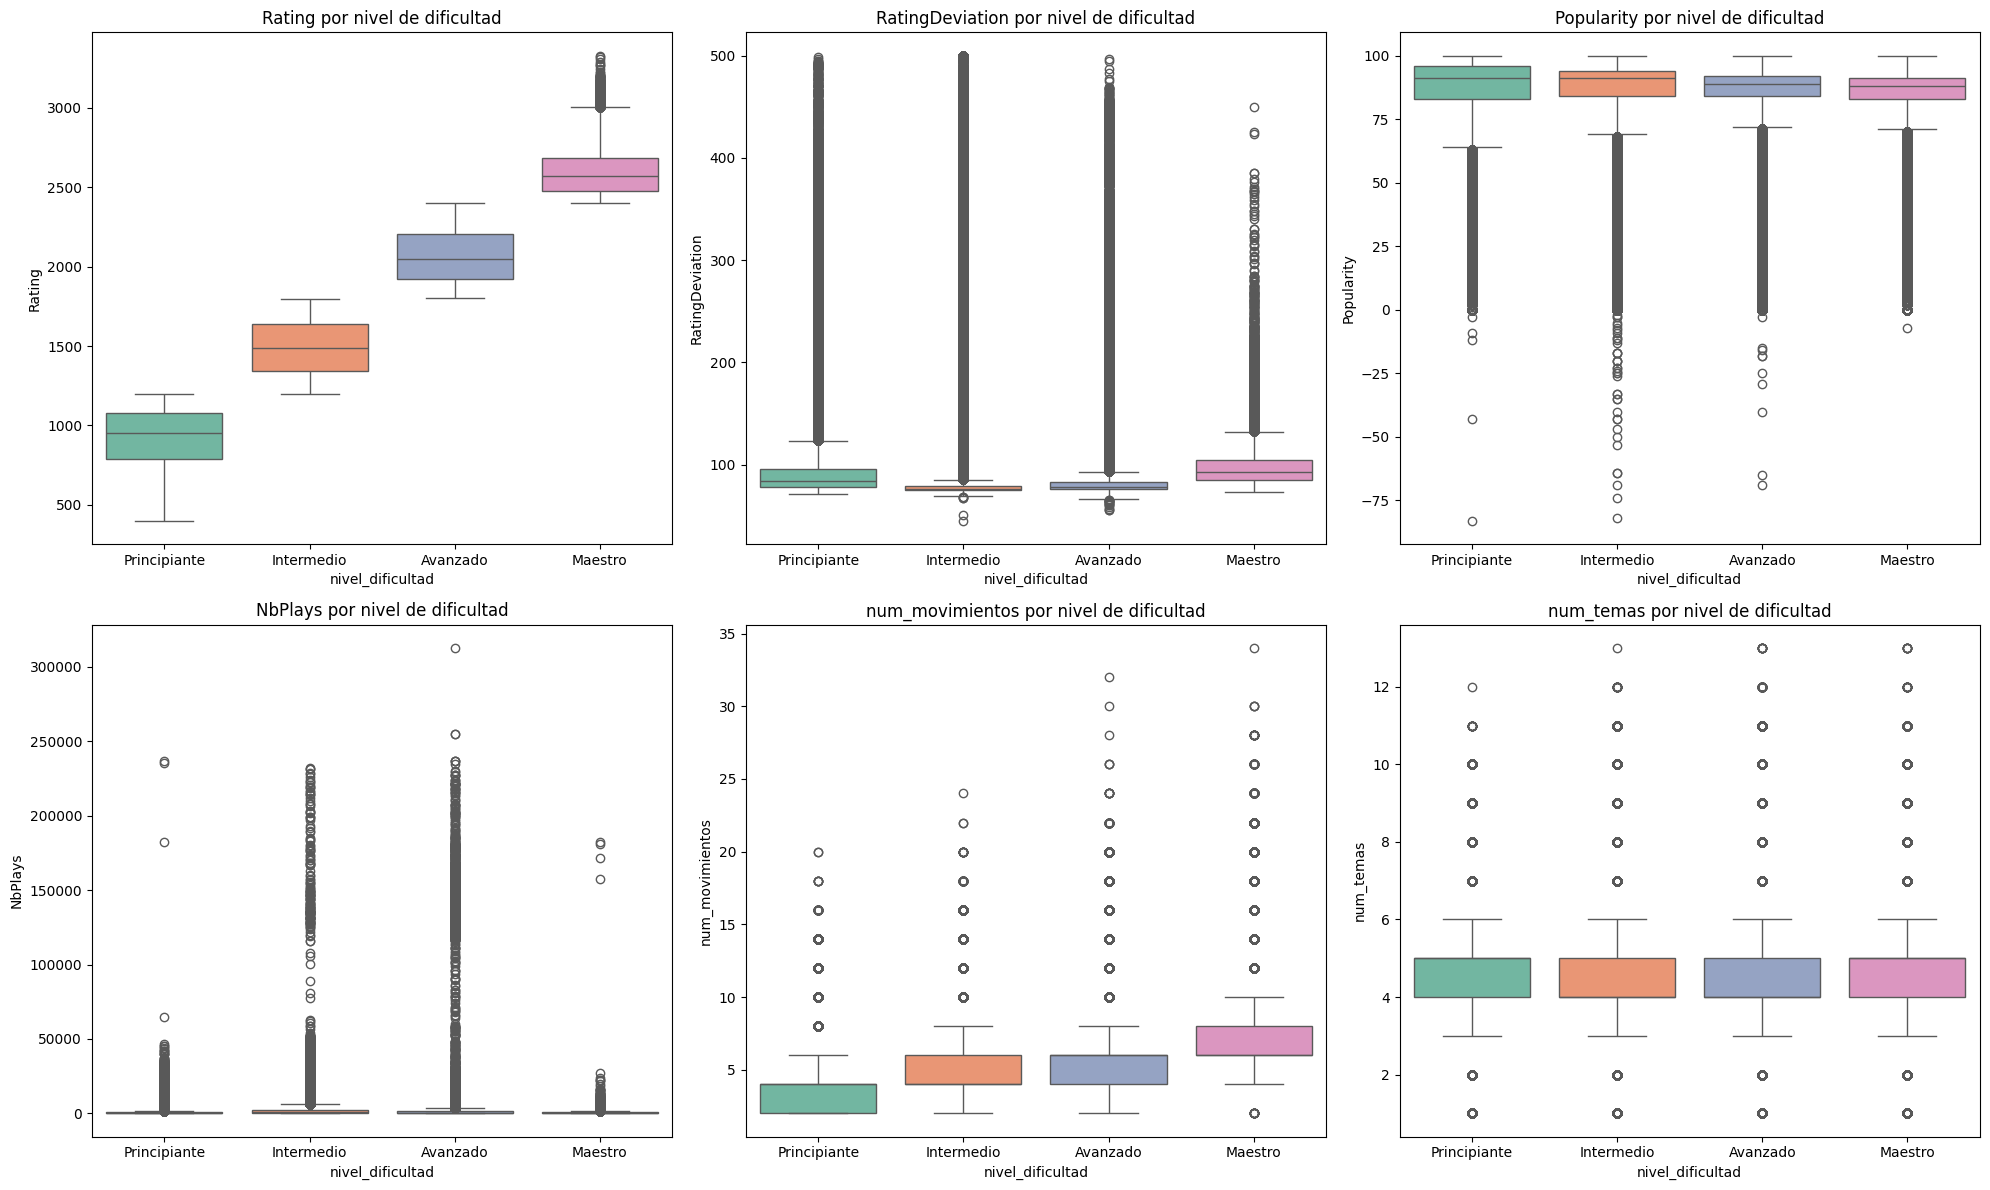

In [ ]:
# ==========================================
# 5. Boxplots agrupados por nivel de dificultad (categórica vs numérica)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12)) # El tamaño se mantiene bien para 6 subplots luego se jode
axes = axes.flatten()
for i, col in enumerate(num_cols):
    # Cambio clave aquí en el eje X
    sns.boxplot(data=df, x='nivel_dificultad', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f"{col} por nivel de dificultad")
    # Con 4 clases podemos dejar la rotación en 0 o 45 grados
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0) 
plt.tight_layout()
plt.show()

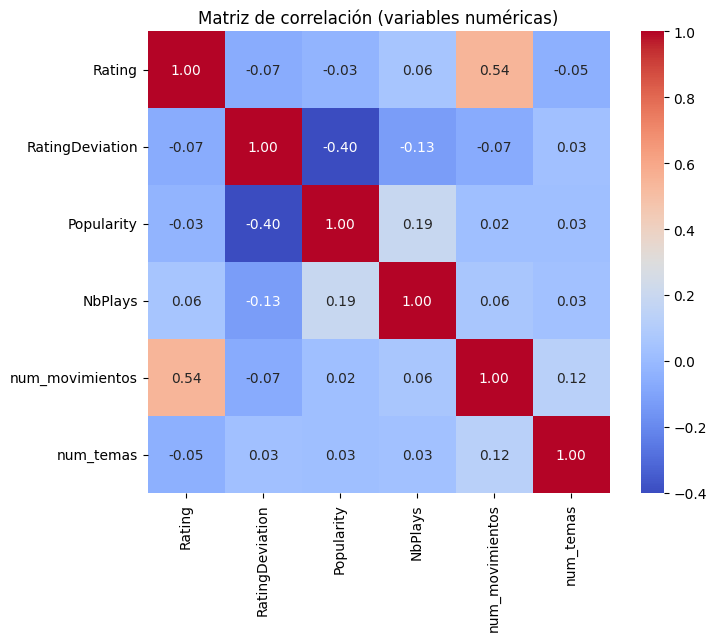

In [ ]:
# ================================
# 6. ANÁLISIS DE CORRELACIÓN (solo numéricas)
# ================================
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


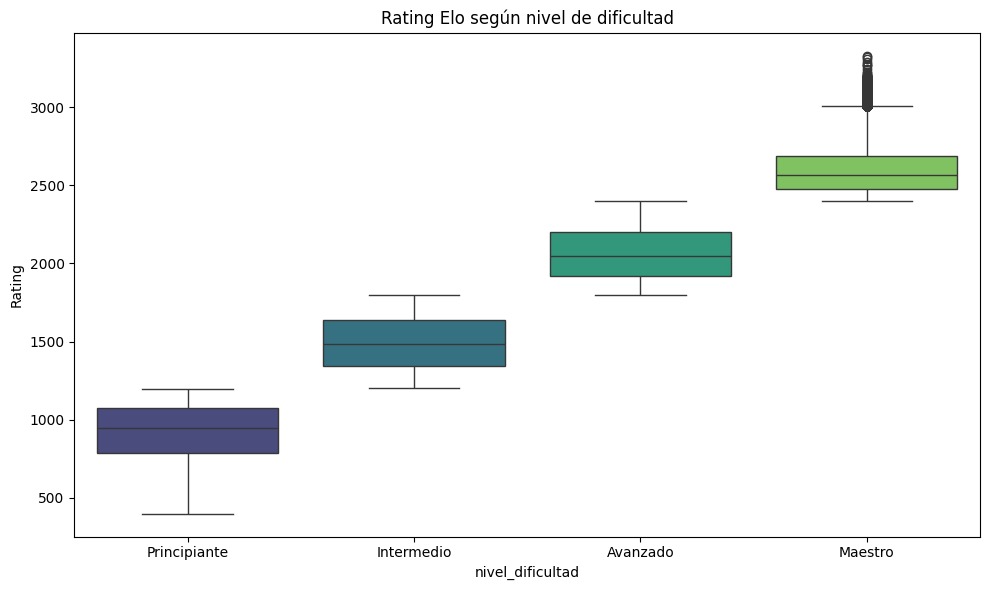

In [ ]:
# ==========================================
# 7. Distribución del Rating por nivel (boxplot más limpio)
# ==========================================
# Podemos reducir un poco el ancho ya son únicamente 4 cajas
plt.figure(figsize=(10, 6)) 
# Cambio clave aquí en el eje X
sns.boxplot(data=df, x='nivel_dificultad', y='Rating', palette='viridis')
plt.title("Rating Elo según nivel de dificultad")
# Quitamos la rotación de 90 grados, NO SE PORQUE, SOLO FUNCIONA
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

In [19]:
# Importar librerías necesarias
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# ==========================================
# 1. IDENTIFICAR VALORES FALTANTES
# ==========================================
print("--- Conteo de Valores Faltantes ---")
faltantes = df.isnull().sum()
faltantes_cols = faltantes[faltantes > 0]

if faltantes_cols.empty:
    print("¡No hay valores faltantes en el dataset!")
else:
    print(faltantes_cols)
    print(f"\nPorcentaje de datos faltantes:\n{(faltantes_cols / len(df) * 100).round(2)}%")

# Solo procedemos si hay numéricas con NAs (evitamos romper el código con categóricas)
cols_imputar = [col for col in faltantes_cols.index if col in num_cols]

if cols_imputar:
    # ==========================================
    # 2. APLICAR DOS MÉTODOS DE IMPUTACIÓN
    # ==========================================
    print("\nIniciando imputación...")
    
    # Copias para no afectar el dataset original todavía
    df_imputado_mediana = df.copy()
    df_imputado_knn = df.copy()
    
    # Método A: Tendencia Central (Mediana es más robusta a outliers que la media)
    imputer_mediana = SimpleImputer(strategy='median')
    df_imputado_mediana[cols_imputar] = imputer_mediana.fit_transform(df[cols_imputar])
    
    # Método B: KNN Imputer (Usa IterativeImputer si tu RAM colapsa en el de ajedrez)
    # imputer_avanzado = IterativeImputer(max_iter=10, random_state=42) # Alternativa rápida
    imputer_avanzado = KNNImputer(n_neighbors=5)
    df_imputado_knn[cols_imputar] = imputer_avanzado.fit_transform(df[cols_imputar])
    print("Imputación finalizada.")

    # ==========================================
    # 3. COMPARAR RESULTADOS (Antes y Después)
    # ==========================================
    print("\n--- Comparación de Estadísticas Descriptivas ---")
    for col in cols_imputar:
        print(f"\nVariable: {col}")
        comp_df = pd.DataFrame({
            'Original (con NAs)': df[col].describe(),
            'Imputado Mediana': df_imputado_mediana[col].describe(),
            'Imputado KNN': df_imputado_knn[col].describe()
        })
        display(comp_df.round(2))
        
        # Comparación visual (Distribución KDE)
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df, x=col, label='Original', fill=True, alpha=0.3, color='blue')
        sns.kdeplot(data=df_imputado_mediana, x=col, label='Mediana', fill=False, color='red', linestyle='--')
        sns.kdeplot(data=df_imputado_knn, x=col, label='KNN', fill=False, color='green', linestyle=':')
        plt.title(f"Impacto de la imputación en la distribución de '{col}'")
        plt.legend()
        plt.show()

--- Conteo de Valores Faltantes ---
OpeningTags    4705599
dtype: int64

Porcentaje de datos faltantes:
OpeningTags    79.99
dtype: float64%


NO hay nada que imputar, la apertura es irrelevante

In [ ]:
# ==========================================
# 8. PRUEBAS DE ASOCIACIÓN Y DEPENDENCIA (Ajedrez)
# ==========================================
from scipy.stats import kruskal

print("--- Kruskal-Wallis: Target Categórico vs Predictoras Numéricas ---\n")
print("Hipótesis Nula (H0): Las medianas de las clases son iguales (No hay dependencia).")
print("Hipótesis Alternativa (H1): Al menos una clase tiene una mediana diferente (Hay dependencia).\n")

# IMPORTANTE: Excluimos 'Rating' porque el nivel_dificultad se deriva directamente de ahí 
num_cols_test = [col for col in num_cols if col != 'Rating']

for col in num_cols_test:
    # Agrupar los datos de la variable numérica por cada clase de dificultad
    # Nota: Usamos dropna() por precaución
    grupos = [df[df['nivel_dificultad'] == clase][col].dropna() for clase in df['nivel_dificultad'].cat.categories]
    
    # Aplicar el test (Kruskal-Wallis requiere desempaquetar la lista de grupos)
    stat, p_value = kruskal(*grupos)
    
    print(f"Variable: **{col}**")
    print(f"  Estadístico H : {stat:.2f}")
    print(f"  P-valor       : {p_value}")
    
    # Interpretación automática (Nivel de significancia alfa = 0.05)
    if p_value < 0.05:
        print("  Interpretación: Rechazamos H0. La variable tiene una asociación significativa con el nivel de dificultad.\n")
    else:
        print("  Interpretación: No se rechaza H0. La variable NO aporta información significativa sobre la dificultad.\n")

--- Kruskal-Wallis: Target Categórico vs Predictoras Numéricas ---

Hipótesis Nula (H0): Las medianas de las clases son iguales (No hay dependencia).
Hipótesis Alternativa (H1): Al menos una clase tiene una mediana diferente (Hay dependencia).

Variable: **RatingDeviation**
  Estadístico H : 1350887.83
  P-valor       : 0.0
  Interpretación: Rechazamos H0. La variable tiene una asociación significativa con el nivel de dificultad.

Variable: **Popularity**
  Estadístico H : 133689.72
  P-valor       : 0.0
  Interpretación: Rechazamos H0. La variable tiene una asociación significativa con el nivel de dificultad.

Variable: **NbPlays**
  Estadístico H : 247820.99
  P-valor       : 0.0
  Interpretación: Rechazamos H0. La variable tiene una asociación significativa con el nivel de dificultad.

Variable: **num_movimientos**
  Estadístico H : 1584040.63
  P-valor       : 0.0
  Interpretación: Rechazamos H0. La variable tiene una asociación significativa con el nivel de dificultad.

Variable: 

# 9. Conclusiones Finales del Análisis Exploratorio (EDA)

Tras evaluar la dependencia de las variables numéricas con la variable objetivo categórica (`nivel_dificultad`), se concluye lo siguiente:

* **Significancia Estadística Generalizada:** La prueba de Kruskal-Wallis rechaza contundentemente la hipótesis nula para todas las variables numéricas evaluadas (`RatingDeviation`, `Popularity`, `NbPlays`, `num_movimientos`, `num_temas`), arrojando p-valores de 0.0. 

* **Validación del Feature Engineering:** A pesar del efecto del tamaño muestral (casi 5.8M), el rechazo de H0 en `num_movimientos` y `num_temas` confirma una de las hiótesis y es que la profundidad de cálculo (cantidad de jugadas) y la complejidad combinatoria (cantidad de temas tácticos simultáneos) son características que varían estructuralmente entre Principiantes, Intermedios, Avanzados y Maestros. Estas variables aportan información valiosa y son ideales para modelos de clasificación multiclase.